In [8]:
from joblib import load
import pandas as pd
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import StandardScaler
import numpy as np
import shap

In [9]:
iron_man = load(r'experiment\202410110954_withallsubjects\iron_man.joblib')

model = iron_man['best_model']
print(iron_man)

{'best_model': GradientBoostingClassifier(n_estimators=7), 'best_genes': array([0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0], dtype=int8), 'best_fitness': 0.8258725765821856, 'best_acc': 0.9099099099099099, 'best_f1': 0.8979591836734694, 'best_recall': 0.8341232227488151, 'best_precision': 0.9723756906077348, 'best_cm': array([[228,   5],
       [ 35, 176]], dtype=int64), 'preds': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

C:\Users\jacop\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DummyClassifier from version 1.4.1.post1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\jacop\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.1.post1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\jacop\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GradientBo

In [10]:
df = pd.read_csv(r'C:\Users\jacop\OneDrive\Desktop\GIST\DATASET\Dataset_features_2D_preproc.csv')
X_train = df.query('subj  in [1,3,4,5,7,9,14,6,12,11,16,8,15]')[df.columns[:-2]].to_numpy()
y_train = df.query('subj  in [1,3,4,5,7,9,14,6,12,11,16,8,15]')[df.columns[-2]].to_numpy()
X_test  = df.query('subj  in [13,10,2]')[df.columns[:-2]].to_numpy()
y_test  = df.query('subj  in [13,10,2]')[df.columns[-2]].to_numpy()
features_name  = df.query('subj  in [13,10,2]')[df.columns[:-2]].columns


imputer,scaler = SimpleImputer(),StandardScaler()
X_train = scaler.fit_transform(imputer.fit_transform(X_train))
X_test  = scaler.transform(imputer.transform(X_test))

In [11]:
iron_man = load(r'experiment\202410101205\iron_man.joblib')

model = iron_man['best_model']
 
genes = iron_man['best_genes']
genes = np.array(genes,dtype = bool)
X_test_selected = X_test[:,genes]

In [12]:
def get_class_feature_importance(model, X_test):
    """
    Returns the SHAP feature importance for class 0 and class 1.
    
    Parameters:
    - model: trained model
    - X_test: test set features (pandas DataFrame or numpy array)
    
    Returns:
    - importance_class_0: SHAP values for class 0
    - importance_class_1: SHAP values for class 1
    """

    # Initialize SHAP explainer
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # SHAP returns two arrays: one for class 0 and one for class 1 (binary classification)
    importance_class_0 = shap_values[0]
    importance_class_1 = shap_values[1]

    return importance_class_0, importance_class_1,shap_values

# Usage example (assuming you have a trained model and a test set):
# importance_0, importance_1 = get_class_feature_importance(trained_model, X_test)


In [13]:
importance_class_0, importance_class_1 ,shap_values= get_class_feature_importance(model, X_test_selected)

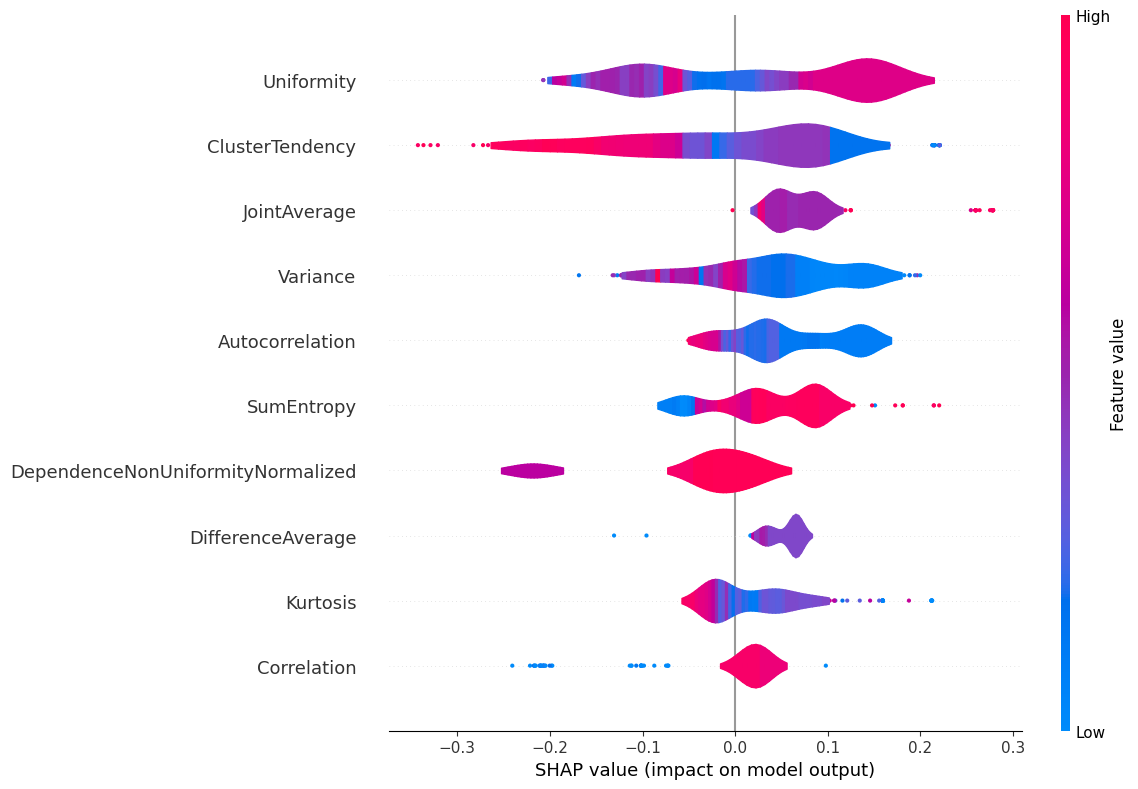

In [15]:
shap.summary_plot(shap_values[:,:,1], X_test_selected,[f.split('_')[1] for f in features_name], plot_type = 'violin', max_display = 10, plot_size = [12,8])